# Notebook 1: Label Construction for 30-Day Hospital Readmission

## Objective
Create binary labels (Y=1 if readmitted, Y=0 otherwise) for predicting 30-day hospital readmissions using MIMIC-IV admissions data.

## Input Data
- `admissions.csv` - Hospital admission records from MIMIC-IV core
- `patients.csv` - Patient demographics and death information

## Process
1. **Load admissions data** - Import all hospital admissions from MIMIC-IV
2. **Exclusion criteria**:
   - Remove admissions where patient died in hospital (`hospital_expire_flag == 1`)
   - Remove transfers to other acute care facilities (HOSPICE, HEALTHCARE FACILITY, etc.)
3. **Label creation logic**:
   - For each discharge (index admission), check if the same patient has another admission within 30 days
   - Label = 1 if readmitted within (0, 30] days
   - Label = 0 if no readmission within 30 days
4. **Temporal consistency** - Sort admissions chronologically per patient to ensure correct readmission detection
5. **Data leakage prevention** - Only use information available up to discharge time

## Output
- `labeled_admissions_30day_readmission.csv` (518,349 admissions)
  - Contains: `hadm_id`, `subject_id`, admission/discharge times, demographics, and **readmitted_30day** label
  - Class distribution: ~20% readmitted (positive class), ~80% not readmitted (negative class)
  - Class imbalance ratio: 4.11:1

## Key Findings
- Started with 523,740 total admissions
- After exclusions: 518,349 eligible index admissions
- Readmission rate: 19.58%
- Average days to readmission: 10.8 days (for readmitted cases)

## Next Step
Notebook 2 will link these labeled admissions to clinical discharge notes.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print("Imported libraries.")

Imported libraries.


In [ ]:
# Define paths
DATA_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/output')

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

# Check what files we have
print("\n" + "-"*60)
print("Available data files:")
print("-"*60)

if DATA_DIR.exists():
    files = list(DATA_DIR.glob('*.csv'))
    if len(files) == 0:
        print("No .csv files found in data directory")
    else:
        for file in sorted(files):
            size_mb = file.stat().st_size / (1024 * 1024)
            print(f"  {file.name:<30} {size_mb:>8.1f} MB")
else:
    print("ERROR: Data directory not found. Please check the path.")

Data directory: /content/drive/MyDrive/MIDS/w266/Final Project/data
Output directory: /content/drive/MyDrive/MIDS/w266/Final Project/output

------------------------------------------------------------
Available data files:
------------------------------------------------------------
  admissions.csv                     89.8 MB
  d_icd_diagnoses.csv                 8.7 MB
  d_labitems.csv                      0.1 MB
  drgcodes.csv                       52.2 MB
  patients.csv                       11.5 MB
  procedures_icd.csv                 32.7 MB
  services.csv                       24.8 MB


In [ ]:
# Load admissions data
print("Loading admissions.csv...")
admissions = pd.read_csv(DATA_DIR / 'admissions.csv')

print(f"Loaded {len(admissions):,} hospital admissions")
print(f"\nDataset shape: {admissions.shape}")
print(f"\nColumns: {admissions.columns.tolist()}")

Loading admissions.csv...
Loaded 546,028 hospital admissions

Dataset shape: (546028, 16)

Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']


In [ ]:
# Display first few rows
print("\nFirst 5 admissions:")
admissions.head()


First 5 admissions:


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


In [ ]:
# Check data types and missing values
print("\nData Info:")
admissions.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            546028 non-null  int64 
 1   hadm_id               546028 non-null  int64 
 2   admittime             546028 non-null  object
 3   dischtime             546028 non-null  object
 4   deathtime             11790 non-null   object
 5   admission_type        546028 non-null  object
 6   admit_provider_id     546024 non-null  object
 7   admission_location    546027 non-null  object
 8   discharge_location    396210 non-null  object
 9   insurance             536673 non-null  object
 10  language              545253 non-null  object
 11  marital_status        532409 non-null  object
 12  race                  546028 non-null  object
 13  edregtime             379240 non-null  object
 14  edouttime             379240 non-null  object
 15  hospi

In [ ]:
# Load patients data
print("Loading patients.csv...")
patients = pd.read_csv(DATA_DIR / 'patients.csv')

print(f"Loaded {len(patients):,} unique patients")
print(f"\nColumns: {patients.columns.tolist()}")
print("\nFirst 5 patients:")
patients.head()

Loading patients.csv...
Loaded 364,627 unique patients

Columns: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']

First 5 patients:


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [ ]:
# Convert datetime columns
print("Converting datetime columns...")

# Admissions dates
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
admissions['deathtime'] = pd.to_datetime(admissions['deathtime'])
admissions['edregtime'] = pd.to_datetime(admissions['edregtime'])
admissions['edouttime'] = pd.to_datetime(admissions['edouttime'])

# Patient death date
patients['dod'] = pd.to_datetime(patients['dod'])

print("Datetime conversion complete")

# Calculate length of stay
admissions['los_days'] = (admissions['dischtime'] - admissions['admittime']).dt.total_seconds() / (24 * 3600)

print(f"\nLength of Stay Statistics:")
print(admissions['los_days'].describe())

Converting datetime columns...
Datetime conversion complete

Length of Stay Statistics:
count    546028.000000
mean          4.761742
std           7.207125
min          -0.945139
25%           1.128472
50%           2.818056
75%           5.621528
max         515.562500
Name: los_days, dtype: float64


In [ ]:
# Basic statistics
print("ADMISSION STATISTICS")
print("="*60)

print(f"\nTotal admissions: {len(admissions):,}")
print(f"Unique patients: {admissions['subject_id'].nunique():,}")
print(f"\nAdmissions per patient:")
admissions_per_patient = admissions.groupby('subject_id').size()
print(admissions_per_patient.describe())

print(f"\nAdmission Types:")
print(admissions['admission_type'].value_counts())

print(f"\nDischarge Locations:")
print(admissions['discharge_location'].value_counts())

ADMISSION STATISTICS

Total admissions: 546,028
Unique patients: 223,452

Admissions per patient:
count    223452.000000
mean          2.443603
std           3.574410
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max         238.000000
dtype: float64

Admission Types:
admission_type
EW EMER.                       177459
EU OBSERVATION                 119456
OBSERVATION ADMIT               84437
URGENT                          54929
SURGICAL SAME DAY ADMISSION     42898
DIRECT OBSERVATION              24551
DIRECT EMER.                    21973
ELECTIVE                        13130
AMBULATORY OBSERVATION           7195
Name: count, dtype: int64

Discharge Locations:
discharge_location
HOME                            194204
HOME HEALTH CARE                 99305
SKILLED NURSING FACILITY         52657
REHAB                            13845
DIED                             11721
CHRONIC/LONG TERM ACUTE CARE      8125
HOSPICE                    

In [ ]:
# Check for in-hospital deaths
print("\nDeath Information:")
print("-"*60)
print(f"Admissions with in-hospital death (deathtime not null): {admissions['deathtime'].notna().sum():,}")
print(f"Admissions with hospital_expire_flag=1: {(admissions['hospital_expire_flag'] == 1).sum():,}")

# These should match
death_mismatch = (admissions['deathtime'].notna() != (admissions['hospital_expire_flag'] == 1)).sum()
print(f"\nMismatch between deathtime and hospital_expire_flag: {death_mismatch}")


Death Information:
------------------------------------------------------------
Admissions with in-hospital death (deathtime not null): 11,790
Admissions with hospital_expire_flag=1: 11,801

Mismatch between deathtime and hospital_expire_flag: 11


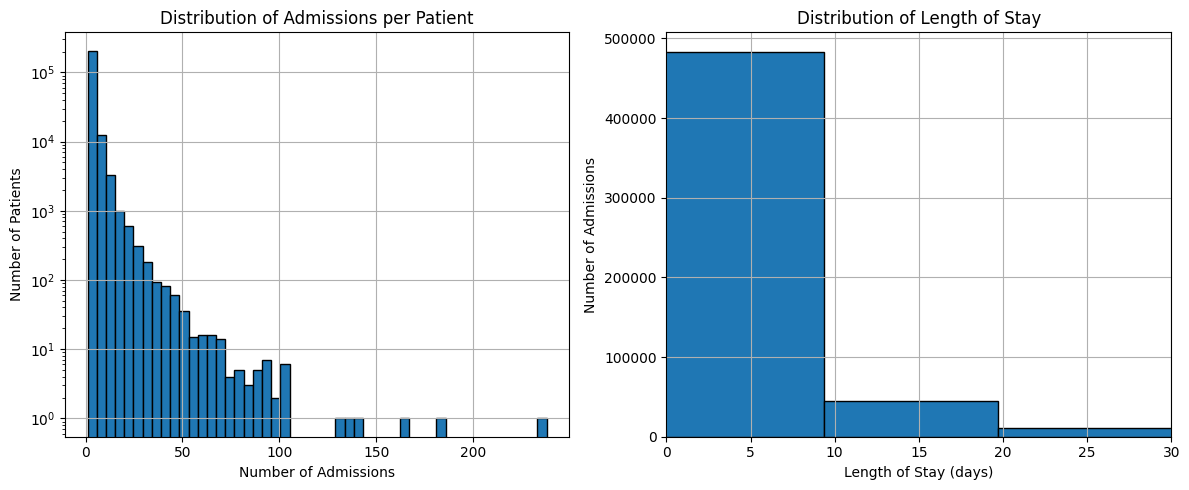

Plot saved to output directory


In [ ]:
# Visualize admissions per patient
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
admissions_per_patient.hist(bins=50, edgecolor='black')
plt.xlabel('Number of Admissions')
plt.ylabel('Number of Patients')
plt.title('Distribution of Admissions per Patient')
plt.yscale('log')

plt.subplot(1, 2, 2)
admissions['los_days'].hist(bins=50, edgecolor='black')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Number of Admissions')
plt.title('Distribution of Length of Stay')
plt.xlim(0, 30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step1_admissions_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to output directory")

In [ ]:
# Step 1: Exclude in-hospital deaths
print("FILTERING INDEX ADMISSIONS")
print("="*60)

print(f"\nStarting admissions: {len(admissions):,}")

# Remove admissions where patient died
admissions_alive = admissions[admissions['hospital_expire_flag'] == 0].copy()
print(f"After removing in-hospital deaths: {len(admissions_alive):,} ({len(admissions_alive)/len(admissions)*100:.1f}%)")

# Step 2: Exclude transfers to other acute care facilities
# Common transfer discharge locations to exclude:
transfer_locations = [
    'HOSPICE',
    'HEALTHCARE FACILITY',
    'ACUTE HOSPITAL',
    'CHRONIC/LONG TERM ACUTE CARE'
]

print(f"\nDischarge locations before filtering:")
print(admissions_alive['discharge_location'].value_counts())

# Keep only non-transfer discharges
index_admissions = admissions_alive[
    ~admissions_alive['discharge_location'].isin(transfer_locations)
].copy()

print(f"\nAfter excluding transfers: {len(index_admissions):,} ({len(index_admissions)/len(admissions)*100:.1f}%)")
print(f"\nDischarge locations after filtering:")
print(index_admissions['discharge_location'].value_counts())

FILTERING INDEX ADMISSIONS

Starting admissions: 546,028
After removing in-hospital deaths: 534,227 (97.8%)

Discharge locations before filtering:
discharge_location
HOME                            194116
HOME HEALTH CARE                 99296
SKILLED NURSING FACILITY         52642
REHAB                            13842
CHRONIC/LONG TERM ACUTE CARE      8121
HOSPICE                           5375
AGAINST ADVICE                    3393
PSYCH FACILITY                    2964
ACUTE HOSPITAL                    2332
OTHER FACILITY                    1591
ASSISTED LIVING                    622
DIED                               227
HEALTHCARE FACILITY                 50
Name: count, dtype: int64

After excluding transfers: 518,349 (94.9%)

Discharge locations after filtering:
discharge_location
HOME                        194116
HOME HEALTH CARE             99296
SKILLED NURSING FACILITY     52642
REHAB                        13842
AGAINST ADVICE                3393
PSYCH FACILITY           

In [ ]:
# Step 3: Sort by patient and admission time
print("\nSorting admissions chronologically...")
index_admissions = index_admissions.sort_values(['subject_id', 'admittime']).reset_index(drop=True)

# Create a copy of all admissions sorted for readmission checking
all_admissions_sorted = admissions[admissions['hospital_expire_flag'] == 0].sort_values(
    ['subject_id', 'admittime']
).reset_index(drop=True)

print(f"Sorted {len(index_admissions):,} index admissions")
print(f"Sorted {len(all_admissions_sorted):,} total admissions for checking readmissions")


Sorting admissions chronologically...
Sorted 518,349 index admissions
Sorted 534,227 total admissions for checking readmissions


In [ ]:
# Step 4: For each index admission, find if there's a readmission within 30 days
print("\nIdentifying 30-day readmissions...")

# Initialize label column
index_admissions['readmitted_30day'] = 0
index_admissions['days_to_readmission'] = np.nan
index_admissions['readmission_hadm_id'] = np.nan

# Group admissions by patient for faster lookup
patient_admissions = all_admissions_sorted.groupby('subject_id')

# Counter for progress
total = len(index_admissions)
readmission_count = 0

for idx, row in index_admissions.iterrows():
    # Progress indicator every 10,000 rows
    if (idx + 1) % 10000 == 0:
        print(f"  Processed {idx + 1:,} / {total:,} ({(idx+1)/total*100:.1f}%)")

    subject_id = row['subject_id']
    discharge_time = row['dischtime']
    current_hadm_id = row['hadm_id']

    # Get all admissions for this patient
    if subject_id not in patient_admissions.groups:
        continue

    patient_admits = patient_admissions.get_group(subject_id)

    # Find admissions that start after this discharge
    future_admits = patient_admits[
        (patient_admits['admittime'] > discharge_time) &
        (patient_admits['hadm_id'] != current_hadm_id)
    ]

    if len(future_admits) > 0:
        # Get the next admission
        next_admit = future_admits.iloc[0]
        days_to_next = (next_admit['admittime'] - discharge_time).total_seconds() / (24 * 3600)

        # Check if within 30 days
        if days_to_next <= 30:
            index_admissions.loc[idx, 'readmitted_30day'] = 1
            index_admissions.loc[idx, 'days_to_readmission'] = days_to_next
            index_admissions.loc[idx, 'readmission_hadm_id'] = next_admit['hadm_id']
            readmission_count += 1

print(f"\nLabel creation complete")
print(f"\nREADMISSION STATISTICS:")
print("-"*60)
print(f"  Total index admissions: {len(index_admissions):,}")
print(f"  Readmitted within 30 days: {readmission_count:,} ({readmission_count/len(index_admissions)*100:.2f}%)")
print(f"  Not readmitted: {len(index_admissions) - readmission_count:,} ({(len(index_admissions) - readmission_count)/len(index_admissions)*100:.2f}%)")


Identifying 30-day readmissions...
  Processed 10,000 / 518,349 (1.9%)
  Processed 20,000 / 518,349 (3.9%)
  Processed 30,000 / 518,349 (5.8%)
  Processed 40,000 / 518,349 (7.7%)
  Processed 50,000 / 518,349 (9.6%)
  Processed 60,000 / 518,349 (11.6%)
  Processed 70,000 / 518,349 (13.5%)
  Processed 80,000 / 518,349 (15.4%)
  Processed 90,000 / 518,349 (17.4%)
  Processed 100,000 / 518,349 (19.3%)
  Processed 110,000 / 518,349 (21.2%)
  Processed 120,000 / 518,349 (23.2%)
  Processed 130,000 / 518,349 (25.1%)
  Processed 140,000 / 518,349 (27.0%)
  Processed 150,000 / 518,349 (28.9%)
  Processed 160,000 / 518,349 (30.9%)
  Processed 170,000 / 518,349 (32.8%)
  Processed 180,000 / 518,349 (34.7%)
  Processed 190,000 / 518,349 (36.7%)
  Processed 200,000 / 518,349 (38.6%)
  Processed 210,000 / 518,349 (40.5%)
  Processed 220,000 / 518,349 (42.4%)
  Processed 230,000 / 518,349 (44.4%)
  Processed 240,000 / 518,349 (46.3%)
  Processed 250,000 / 518,349 (48.2%)
  Processed 260,000 / 518,34


LABEL DISTRIBUTION:
readmitted_30day
0    416831
1    101518
Name: count, dtype: int64

Days to Readmission (for readmitted cases):
count    101518.000000
mean         10.819471
std           8.496423
min           0.000694
25%           3.365972
50%           9.072569
75%          17.142361
max          29.999306
Name: days_to_readmission, dtype: float64


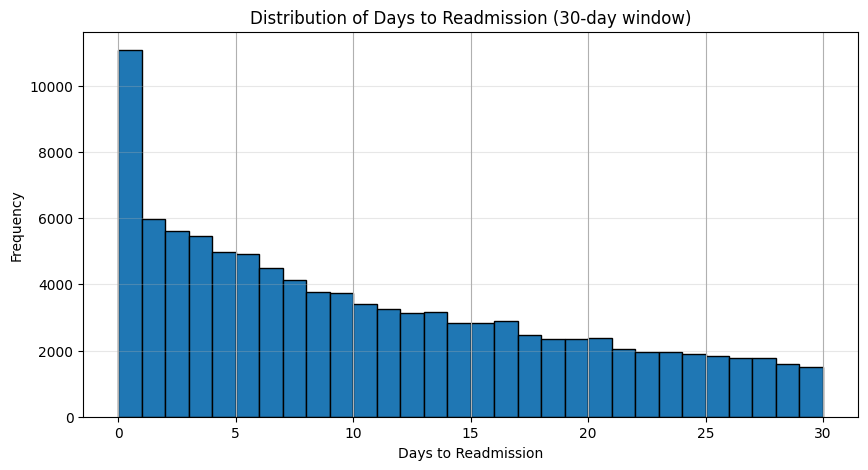

In [ ]:
# Analyze the labels
print("\nLABEL DISTRIBUTION:")
print(index_admissions['readmitted_30day'].value_counts())

print("\nDays to Readmission (for readmitted cases):")
print(index_admissions[index_admissions['readmitted_30day'] == 1]['days_to_readmission'].describe())

# Plot distribution of days to readmission
plt.figure(figsize=(10, 5))
index_admissions[index_admissions['readmitted_30day'] == 1]['days_to_readmission'].hist(bins=30, edgecolor='black')
plt.xlabel('Days to Readmission')
plt.ylabel('Frequency')
plt.title('Distribution of Days to Readmission (30-day window)')
plt.grid(axis='y', alpha=0.3)
plt.savefig(OUTPUT_DIR / 'step1_days_to_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Select important columns to save
columns_to_save = [
    'subject_id',
    'hadm_id',
    'admittime',
    'dischtime',
    'admission_type',
    'admission_location',
    'discharge_location',
    'insurance',
    'language',
    'marital_status',
    'race',
    'los_days',
    'readmitted_30day',
    'days_to_readmission',
    'readmission_hadm_id'
]

# Create final labeled dataset
labeled_dataset = index_admissions[columns_to_save].copy()

# Save to CSV
output_file = OUTPUT_DIR / 'labeled_admissions_30day_readmission.csv'
labeled_dataset.to_csv(output_file, index=False)

print(f"Saved labeled dataset to: {output_file}")
print(f"\nFinal dataset shape: {labeled_dataset.shape}")
print(f"\nClass balance:")
print(labeled_dataset['readmitted_30day'].value_counts(normalize=True))

Saved labeled dataset to: /content/drive/MyDrive/MIDS/w266/Final Project/output/labeled_admissions_30day_readmission.csv

Final dataset shape: (518349, 15)

Class balance:
readmitted_30day
0    0.804151
1    0.195849
Name: proportion, dtype: float64


In [ ]:
# Final summary
print("\n" + "="*60)
print("STEP 1 COMPLETE: 30-DAY READMISSION LABELS CREATED")
print("="*60)

print(f"\nTotal labeled admissions: {len(labeled_dataset):,}")
print(f"Positive cases (readmitted): {(labeled_dataset['readmitted_30day'] == 1).sum():,}")
print(f"Negative cases (not readmitted): {(labeled_dataset['readmitted_30day'] == 0).sum():,}")
print(f"Class imbalance ratio: {(labeled_dataset['readmitted_30day'] == 0).sum() / (labeled_dataset['readmitted_30day'] == 1).sum():.2f}:1")
print(f"\nOutput saved to: {output_file}")
print(f"\nReady for Step 2: Feature Engineering")


STEP 1 COMPLETE: 30-DAY READMISSION LABELS CREATED

Total labeled admissions: 518,349
Positive cases (readmitted): 101,518
Negative cases (not readmitted): 416,831
Class imbalance ratio: 4.11:1

Output saved to: /content/drive/MyDrive/MIDS/w266/Final Project/output/labeled_admissions_30day_readmission.csv

Ready for Step 2: Feature Engineering
